<a href="https://colab.research.google.com/github/Florence-01-17/Masters_Research/blob/main/Machine_Learning_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [ ]:
#upload files
uploaded = files.upload()

Saving 2025 Chl.xlsx to 2025 Chl.xlsx
Saving 2019 Chl.xlsx to 2019 Chl.xlsx
Saving 2020 Chl.xlsx to 2020 Chl.xlsx
Saving 2021 Chl.xlsx to 2021 Chl.xlsx
Saving 2022 Chl.xlsx to 2022 Chl.xlsx
Saving 2023 Chl.xlsx to 2023 Chl.xlsx
Saving 2024 Chl.xlsx to 2024 Chl.xlsx


In [ ]:
#Read the files
df2019 = pd.read_excel("2019 Chl.xlsx")
df2020 = pd.read_excel("2020 Chl.xlsx")
df2021 = pd.read_excel("2021 Chl.xlsx")
df2022 = pd.read_excel("2022 Chl.xlsx")
df2023 = pd.read_excel("2023 Chl.xlsx")
df2024 = pd.read_excel("2024 Chl.xlsx")
df2025 = pd.read_excel("2025 Chl.xlsx")

In [ ]:
#merge everything
df = pd.concat([
    df2019,
    df2020,
    df2021,
    df2022,
    df2023,
    df2024,
    df2025
], ignore_index=True)

In [ ]:
#convert the date
df["date"] = pd.to_datetime(df["date"])

df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month

In [ ]:
# Correlation Matrix
correlation = df[[
    "B3",
    "B4",
    "B5",
    "B8",
    "NDWI",
    "Chlorophyll_a"
]].corr()

print(correlation)

                     B3        B4        B5        B8      NDWI  Chlorophyll_a
B3             1.000000  0.864304  0.807083  0.240463  0.127601       0.148464
B4             0.864304  1.000000  0.784901  0.071646  0.186533       0.413881
B5             0.807083  0.784901  1.000000  0.656736 -0.387979      -0.220395
B8             0.240463  0.071646  0.656736  1.000000 -0.901658      -0.827540
NDWI           0.127601  0.186533 -0.387979 -0.901658  1.000000       0.847718
Chlorophyll_a  0.148464  0.413881 -0.220395 -0.827540  0.847718       1.000000


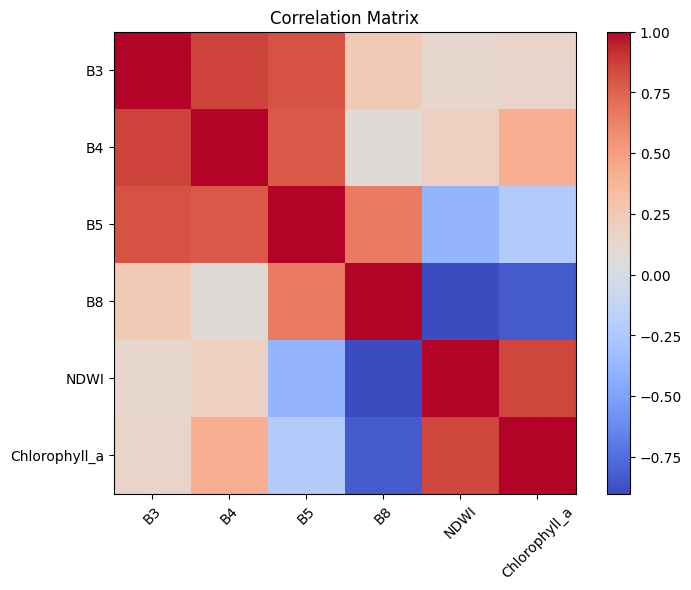

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=45)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
encoder = LabelEncoder()

df["field_id"] = encoder.fit_transform(df["field_id"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   B3             4368 non-null   float64       
 1   B4             4368 non-null   float64       
 2   B5             4368 non-null   float64       
 3   B8             4368 non-null   float64       
 4   NDCI           4368 non-null   float64       
 5   NDWI           4368 non-null   float64       
 6   date           4368 non-null   datetime64[ns]
 7   field_id       4368 non-null   int64         
 8   Chlorophyll_a  3843 non-null   float64       
 9   Year           4368 non-null   int32         
 10  Month          4368 non-null   int32         
dtypes: datetime64[ns](1), float64(7), int32(2), int64(1)
memory usage: 341.4 KB


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Select only predictor variables (exclude the target)
X = df[[
    "B3",
    "B4",
    "B5",
    "B8",
    "NDCI",
    "NDWI",
    "Month",
    "field_id",
    "Chlorophyll_a"
]]

selector = VarianceThreshold(threshold=0.001)

X_selected = selector.fit_transform(X)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['B8', 'NDCI', 'NDWI', 'Month', 'field_id', 'Chlorophyll_a'], dtype='object')


In [ ]:
removed_features = X.columns[~selector.get_support()]

print("Removed Features:")
print(list(removed_features))

Removed Features:
['B3', 'B4', 'B5']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   B3             4368 non-null   float64       
 1   B4             4368 non-null   float64       
 2   B5             4368 non-null   float64       
 3   B8             4368 non-null   float64       
 4   NDCI           4368 non-null   float64       
 5   NDWI           4368 non-null   float64       
 6   date           4368 non-null   datetime64[ns]
 7   field_id       4368 non-null   int64         
 8   Chlorophyll_a  3843 non-null   float64       
 9   Year           4368 non-null   int32         
 10  Month          4368 non-null   int32         
dtypes: datetime64[ns](1), float64(7), int32(2), int64(1)
memory usage: 341.4 KB


In [ ]:
encoder = LabelEncoder()

df["field_id"] = encoder.fit_transform(df["field_id"])

In [ ]:
df = df[
    [
        "Year",
        "Month",
        "field_id",
        "B3",
        "B4",
        "B5",
        "B8",
        "NDWI",
        "Chlorophyll_a"
    ]
]

In [ ]:
#next years chlorophyll by matching the same month and field_id
future = df[
    ["Year","Month","field_id","Chlorophyll_a"]
].copy()

future["Year"] = future["Year"] - 1

future.rename(
    columns={
        "Chlorophyll_a":"Target_Chlorophyll_a"
    },
    inplace=True
)

In [ ]:
#for every 2019 observation, it attaches the chlorophyll from 2020 etc
forecast_df = pd.merge(
    df,
    future,
    on=["Year","Month","field_id"]
)

In [ ]:
df.describe()

,Year,Month,field_id,B3,B4,B5,B8,NDWI,Chlorophyll_a
count,4368.000000,4368.000000,4368.000000,4368.000000,4368.000000,4368.000000,4368.000000,4368.000000,3843.000000
mean,2022.000000,6.500000,25.500000,0.086208,0.091229,0.112665,0.135106,-0.137016,7.970312
std,2.000229,3.452448,15.010049,0.017770,0.020465,0.023004,0.061783,0.211640,2.798660
min,2019.000000,1.000000,0.000000,0.033818,0.030057,0.043422,0.028968,-0.633310,-3.276127
25%,2020.000000,3.750000,12.750000,0.074758,0.077854,0.096256,0.086045,-0.314518,6.728295
50%,2022.000000,6.500000,25.500000,0.084670,0.089552,0.109259,0.116773,-0.090875,8.985087
75%,2024.000000,9.250000,38.250000,0.095591,0.103295,0.126171,0.180892,0.029536,10.043723
max,2025.000000,12.000000,51.000000,0.200868,0.194496,0.221044,0.336689,0.340800,11.284733


In [ ]:
forecast_df.head()

,Year,Month,field_id,B3,B4,B5,B8,NDWI,Chlorophyll_a,Target_Chlorophyll_a
0,2019,1,0,0.093805,0.097607,0.115912,0.129831,-0.15162,8.287912,8.760827
1,2019,1,1,0.104443,0.107250,0.117422,0.110061,-0.04707,9.896758,10.380086
2,2019,1,2,0.096056,0.076533,0.122517,0.229038,-0.41317,1.733530,3.131061
3,2019,1,3,0.140601,0.116401,0.165077,0.264747,-0.32359,3.813707,1.112466
4,2019,1,4,0.106984,0.089428,0.131448,0.240606,-0.40775,3.028366,0.769670


In [ ]:
forecast_df.tail()

,Year,Month,field_id,B3,B4,B5,B8,NDWI,Chlorophyll_a,Target_Chlorophyll_a
3739,2024,12,47,0.103866,0.111504,0.127876,0.116537,0.036237,9.603337,9.145404
3740,2024,12,48,0.093036,0.099025,0.112438,0.100468,0.047626,9.787599,9.693755
3741,2024,12,49,0.091698,0.096373,0.109271,0.098372,0.059827,9.622901,9.261870
3742,2024,12,50,0.096709,0.102615,0.107757,0.063353,0.209099,10.930093,10.969322
3743,2024,12,51,0.100454,0.106834,0.117468,0.090856,0.096502,10.145599,10.012776


In [ ]:
 #defining x and y
X = forecast_df[
    [
        "B3",
        "B4",
        "B5",
        "B8",
        "NDWI",
        "Month",
        "field_id",
        "Chlorophyll_a"
    ]
]

y = forecast_df["Target_Chlorophyll_a"]

In [ ]:
train = forecast_df[forecast_df["Year"] < 2024]

test = forecast_df[forecast_df["Year"] == 2024]

In [ ]:
X_train = train[X.columns]
y_train = train["Target_Chlorophyll_a"]

X_test = test[X.columns]
y_test = test["Target_Chlorophyll_a"]

In [ ]:
#checking for missing values
print("NaN in X_train:")
print(X_train.isnull().sum())

print("\nNaN in y_train:")
print(y_train.isnull().sum())

NaN in X_train:
B3                 0
B4                 0
B5                 0
B8                 0
NDWI               0
Month              0
field_id           0
Chlorophyll_a    525
dtype: int64

NaN in y_train:
525


In [ ]:
print(y_train[y_train.isna()])

1347   NaN
1348   NaN
1349   NaN
1350   NaN
1351   NaN
        ..
1867   NaN
1868   NaN
1869   NaN
1870   NaN
1871   NaN
Name: Target_Chlorophyll_a, Length: 525, dtype: float64


In [ ]:
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3744 entries, 0 to 3743
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  3744 non-null   int32  
 1   Month                 3744 non-null   int32  
 2   field_id              3744 non-null   int64  
 3   B3                    3744 non-null   float64
 4   B4                    3744 non-null   float64
 5   B5                    3744 non-null   float64
 6   B8                    3744 non-null   float64
 7   NDWI                  3744 non-null   float64
 8   Chlorophyll_a         3219 non-null   float64
 9   Target_Chlorophyll_a  3219 non-null   float64
dtypes: float64(7), int32(2), int64(1)
memory usage: 263.4 KB


In [ ]:
forecast_df["Target_Chlorophyll_a"].isnull().sum()

np.int64(525)

In [ ]:
forecast_df["Chlorophyll_a"].isnull().sum()

np.int64(525)

In [ ]:
forecast_df = forecast_df.dropna(subset=["Target_Chlorophyll_a"])

In [ ]:
forecast_df = forecast_df.dropna(subset=["Chlorophyll_a"])

In [ ]:
forecast_df.head(10)

,Year,Month,field_id,B3,B4,B5,B8,NDWI,Chlorophyll_a,Target_Chlorophyll_a
0,2019,1,0,0.093805,0.097607,0.115912,0.129831,-0.15162,8.287912,8.760827
1,2019,1,1,0.104443,0.107250,0.117422,0.110061,-0.04707,9.896758,10.380086
2,2019,1,2,0.096056,0.076533,0.122517,0.229038,-0.41317,1.733530,3.131061
3,2019,1,3,0.140601,0.116401,0.165077,0.264747,-0.32359,3.813707,1.112466
4,2019,1,4,0.106984,0.089428,0.131448,0.240606,-0.40775,3.028366,0.769670
5,2019,1,5,0.087297,0.081000,0.117137,0.200241,-0.37635,3.967326,3.075309
6,2019,1,6,0.068595,0.061400,0.095046,0.163278,-0.39745,3.070481,4.407777
7,2019,1,7,0.069862,0.056691,0.098166,0.196400,-0.43897,1.474572,5.415213
8,2019,1,8,0.074613,0.061147,0.100031,0.192567,-0.41511,2.523212,5.205403
9,2019,1,9,0.088529,0.074813,0.112270,0.195894,-0.35312,4.028233,6.092949


In [ ]:
forecast_df.tail(10)

,Year,Month,field_id,B3,B4,B5,B8,NDWI,Chlorophyll_a,Target_Chlorophyll_a
3734,2024,12,42,0.111680,0.128138,0.167680,0.247765,-0.375540,7.002013,1.933586
3735,2024,12,43,0.113910,0.128501,0.162897,0.219915,-0.281640,7.709900,4.803688
3736,2024,12,44,0.090421,0.094430,0.101403,0.065763,0.158560,10.534719,10.747503
3737,2024,12,45,0.102211,0.110284,0.123212,0.105235,0.053504,9.980366,9.645919
3738,2024,12,46,0.096134,0.102149,0.107252,0.063373,0.205761,10.932438,11.105080
3739,2024,12,47,0.103866,0.111504,0.127876,0.116537,0.036237,9.603337,9.145404
3740,2024,12,48,0.093036,0.099025,0.112438,0.100468,0.047626,9.787599,9.693755
3741,2024,12,49,0.091698,0.096373,0.109271,0.098372,0.059827,9.622901,9.261870
3742,2024,12,50,0.096709,0.102615,0.107757,0.063353,0.209099,10.930093,10.969322
3743,2024,12,51,0.100454,0.106834,0.117468,0.090856,0.096502,10.145599,10.012776


In [ ]:
train = forecast_df[forecast_df["Year"] < 2024]

test = forecast_df[forecast_df["Year"] == 2024]

X_train = train[X.columns]
y_train = train["Target_Chlorophyll_a"]

X_test = test[X.columns]
y_test = test["Target_Chlorophyll_a"]

In [ ]:
#train random forest
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
#Predict
pred = rf.predict(X_test)

In [ ]:
#evaluate
print("R2 =",r2_score(y_test,pred))

print("RMSE =",np.sqrt(mean_squared_error(y_test,pred)))

print("MAE =",mean_absolute_error(y_test,pred))

R2 = 0.5254746231354415
RMSE = 1.575011503727034
MAE = 0.9121814325286414


In [ ]:
#feature importance
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

         Feature  Importance
7  Chlorophyll_a    0.779838
4           NDWI    0.055501
3             B8    0.044503
0             B3    0.028973
5          Month    0.024067
6       field_id    0.023042
1             B4    0.022441
2             B5    0.021635


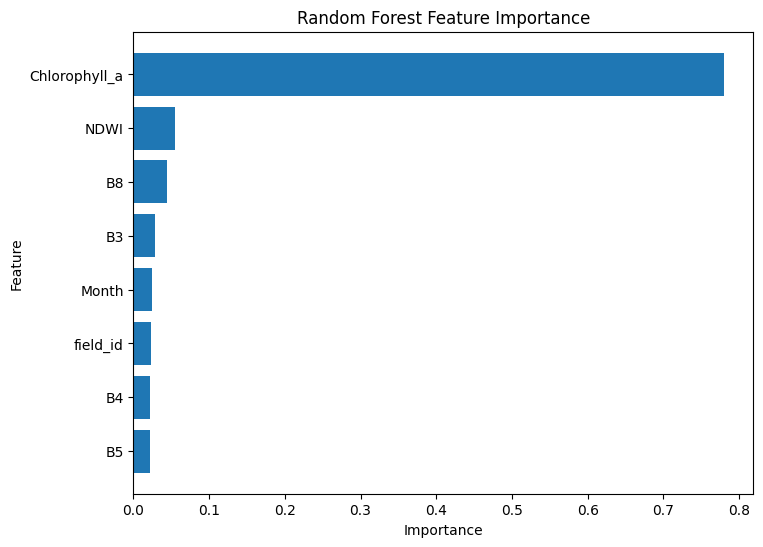

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Parameter grid
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross-validation R²:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-validation R²:
0.47561581035445444


In [ ]:
#train optimised model
best_randomforest = grid_search.best_estimator_

best_randomforest.fit(X_train, y_train)

pred = best_randomforest.predict(X_test)

In [ ]:
#evaluate optimised model
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("Optimized Random Forest Results")
print("----------------------")
print("R² =", r2)
print("RMSE =", rmse)
print("MAE =", mae)

Optimized Random Forest Results
----------------------
R² = 0.5316147020588785
RMSE = 1.5647884653702966
MAE = 0.9137941960162116


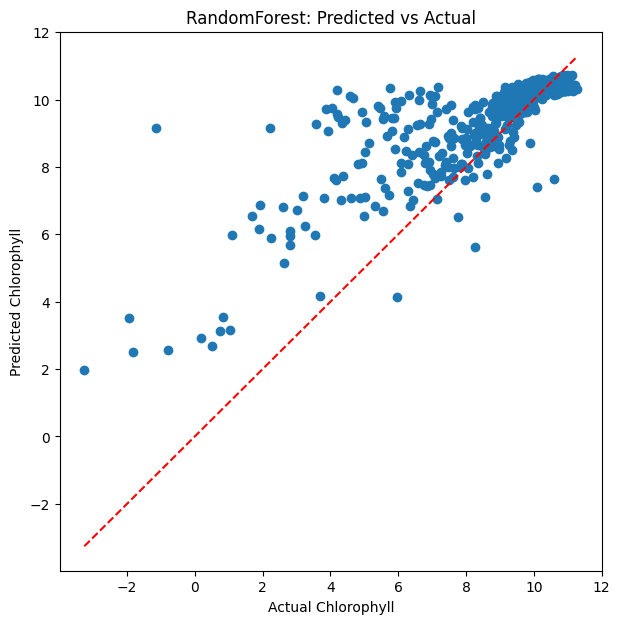

In [ ]:
#Predicted vs Actual plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Chlorophyll")
plt.ylabel("Predicted Chlorophyll")
plt.title("RandomForest: Predicted vs Actual")

plt.show()

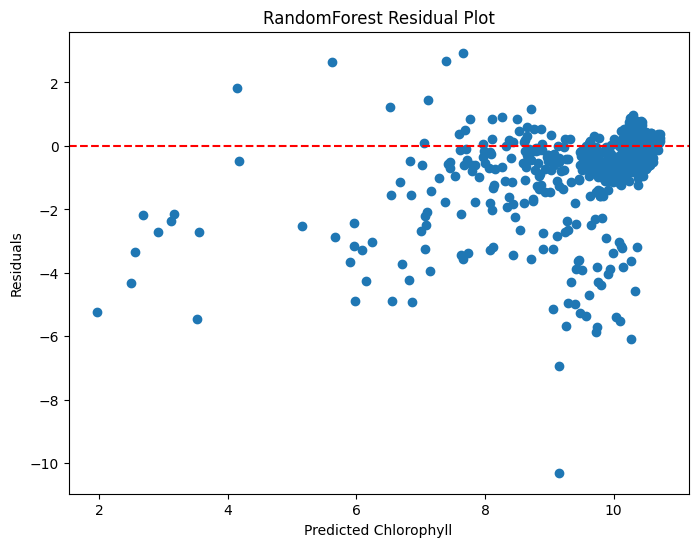

In [ ]:
#residual plot
residuals = y_test - pred

plt.figure(figsize=(8,6))

plt.scatter(pred, residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Chlorophyll")
plt.ylabel("Residuals")

plt.title("RandomForest Residual Plot")

plt.show()

In [ ]:
#Taking the entire 2025 dataset and using it as input
prediction_2026 = df[df["Year"]==2025].copy()

In [ ]:
#predict 2026
X_2026 = prediction_2026[X_train.columns]
prediction_2026["Predicted_Chlorophyll_2026_RF"] = best_randomforest.predict(X_2026)

prediction_2026.head()

,Year,Month,field_id,B3,B4,B5,B8,NDWI,Chlorophyll_a,Predicted_Chlorophyll_2026_RF
3744,2025,1,0,0.090278,0.100278,0.111060,0.076112,0.109067,9.985310,10.230507
3745,2025,1,1,0.087753,0.092283,0.099603,0.052599,0.255062,10.447196,10.009063
3746,2025,1,2,0.087376,0.103112,0.123464,0.132039,-0.192650,8.559337,8.034297
3747,2025,1,3,0.129993,0.129922,0.162884,0.203147,-0.233950,7.202611,7.475522
3748,2025,1,4,0.167733,0.172509,0.196704,0.174084,-0.018210,9.277556,8.318699


In [ ]:
#XGBoost model
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
#baseline model
xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [ ]:
#train model
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#make prediction
pred_xgb = xgb.predict(X_test)

In [ ]:
#model evaluation

print("R² =", r2_score(y_test, pred_xgb))

print("RMSE =", np.sqrt(mean_squared_error(y_test, pred_xgb)))

print("MAE =", mean_absolute_error(y_test, pred_xgb))

R² = 0.5273690965068114
RMSE = 1.5718643575756672
MAE = 0.9258489307130853


In [ ]:
#feature importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

         Feature  Importance
7  Chlorophyll_a    0.594700
4           NDWI    0.162208
5          Month    0.065421
3             B8    0.053700
6       field_id    0.032650
1             B4    0.032623
0             B3    0.030259
2             B5    0.028439


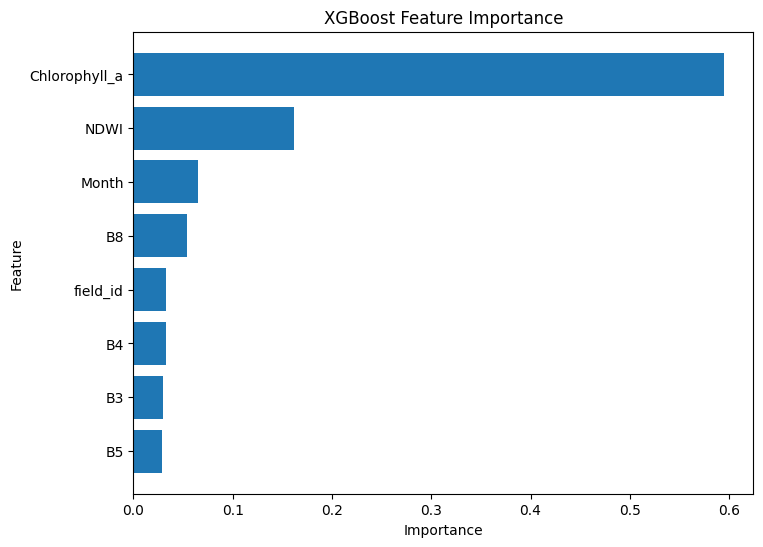

In [ ]:
#plot feature importance
plt.figure(figsize=(8,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
#hypertuning parameter
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters")
print(grid.best_params_)

print("Best CV Score")
print(grid.best_score_)

Best Parameters
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV Score
0.46636726071371226


In [ ]:
#train optimised model
best_xgboost = grid.best_estimator_

best_xgboost.fit(X_train, y_train)

pred_xgb = best_xgboost.predict(X_test)

In [ ]:
#evaluate optimised model
r2 = r2_score(y_test, pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae = mean_absolute_error(y_test, pred_xgb)

print("Optimized XGBoost Results")
print("----------------------")
print("R² =", r2)
print("RMSE =", rmse)
print("MAE =", mae)

Optimized XGBoost Results
----------------------
R² = 0.52670835185243
RMSE = 1.5729627180751902
MAE = 0.9122984735693643


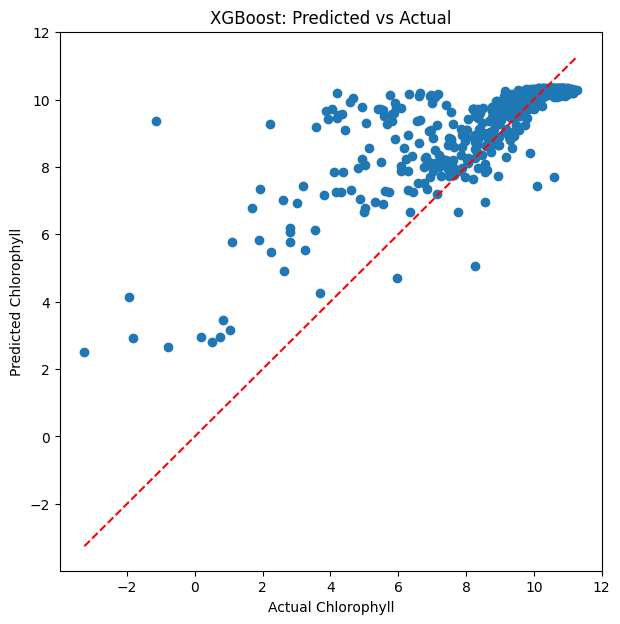

In [ ]:
#Predicted vs Actual plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, pred_xgb)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Chlorophyll")
plt.ylabel("Predicted Chlorophyll")
plt.title("XGBoost: Predicted vs Actual")

plt.show()

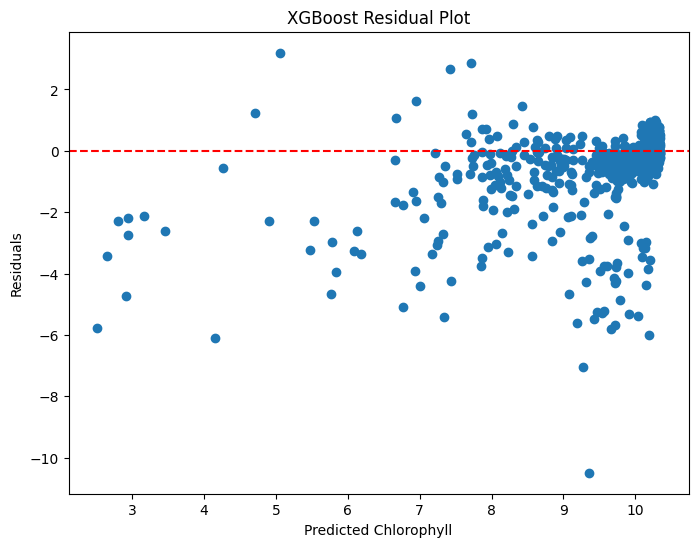

In [ ]:
#residual plot
residuals = y_test - pred_xgb

plt.figure(figsize=(8,6))

plt.scatter(pred_xgb, residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Chlorophyll")
plt.ylabel("Residuals")

plt.title("XGBoost Residual Plot")

plt.show()

In [ ]:
#Taking the entire 2025 dataset and using it as input
prediction_2026 = df[df["Year"]==2025].copy()

In [ ]:
#predict 2026
X_2026 = prediction_2026[X_train.columns]
prediction_2026["Predicted_Chlorophyll_2026_XGB"] = best_xgboost.predict(X_2026)

prediction_2026.head()

,Year,Month,field_id,B3,B4,B5,B8,NDWI,Chlorophyll_a,Predicted_Chlorophyll_2026_XGB
3744,2025,1,0,0.090278,0.100278,0.111060,0.076112,0.109067,9.985310,10.103300
3745,2025,1,1,0.087753,0.092283,0.099603,0.052599,0.255062,10.447196,10.209600
3746,2025,1,2,0.087376,0.103112,0.123464,0.132039,-0.192650,8.559337,8.086679
3747,2025,1,3,0.129993,0.129922,0.162884,0.203147,-0.233950,7.202611,7.180325
3748,2025,1,4,0.167733,0.172509,0.196704,0.174084,-0.018210,9.277556,8.382053


In [ ]:
#standardise the data
# Create the scaler
scaler = StandardScaler()

# Learn the scaling from the training data and scale it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the test data
X_test_scaled = scaler.transform(X_test)

In [ ]:
svr = SVR(
    kernel='rbf',
    C=10,
    gamma='scale',
    epsilon=0.1
)

In [ ]:
#train model
svr.fit(X_train_scaled, y_train)

SVR(C=10)

In [ ]:
#make predictions
pred_svr = svr.predict(X_test_scaled)

In [ ]:
#evaluate model
r2 = r2_score(y_test, pred_svr)
rmse = np.sqrt(mean_squared_error(y_test, pred_svr))
mae = mean_absolute_error(y_test, pred_svr)

print("R² =", r2)
print("RMSE =", rmse)
print("MAE =", mae)

R² = 0.5221268332786483
RMSE = 1.5805576141181708
MAE = 0.9308217915052673


In [ ]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5]
}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Cross-validation R²:")
print(grid.best_score_)

Best Parameters:
{'C': 1, 'epsilon': 0.5, 'gamma': 0.01}
Best Cross-validation R²:
0.502322345141063


In [ ]:
#train optimised model
best_svr = grid.best_estimator_

best_svr.fit(X_train_scaled, y_train)

pred_svr = best_svr.predict(X_test_scaled)

In [ ]:
#evaluate optimised model
r2 = r2_score(y_test, pred_svr)
rmse = np.sqrt(mean_squared_error(y_test, pred_svr))
mae = mean_absolute_error(y_test, pred_svr)

print("Optimized SVR Results")
print("----------------------")
print("R² =", r2)
print("RMSE =", rmse)
print("MAE =", mae)

Optimized SVR Results
----------------------
R² = 0.5294658854655155
RMSE = 1.5683737569829252
MAE = 0.9261725129942846


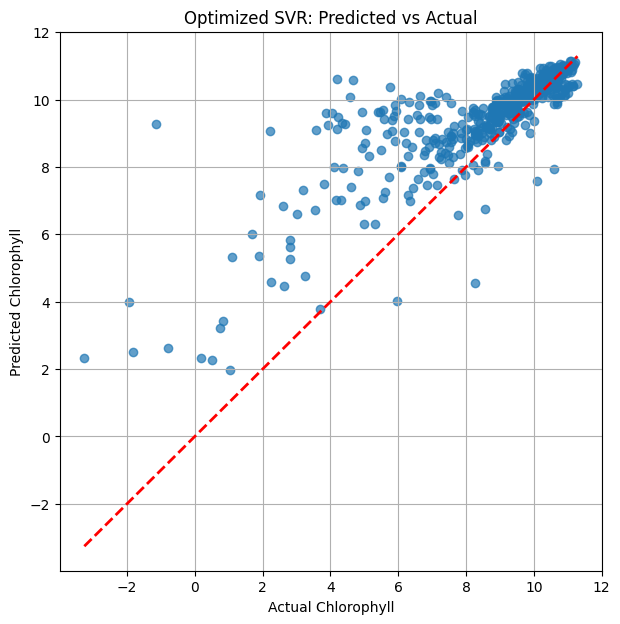

In [ ]:
#Predicted vs Actual plot
plt.figure(figsize=(7,7))

plt.scatter(y_test, pred_svr, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Chlorophyll")
plt.ylabel("Predicted Chlorophyll")
plt.title("Optimized SVR: Predicted vs Actual")

plt.grid(True)

plt.show()

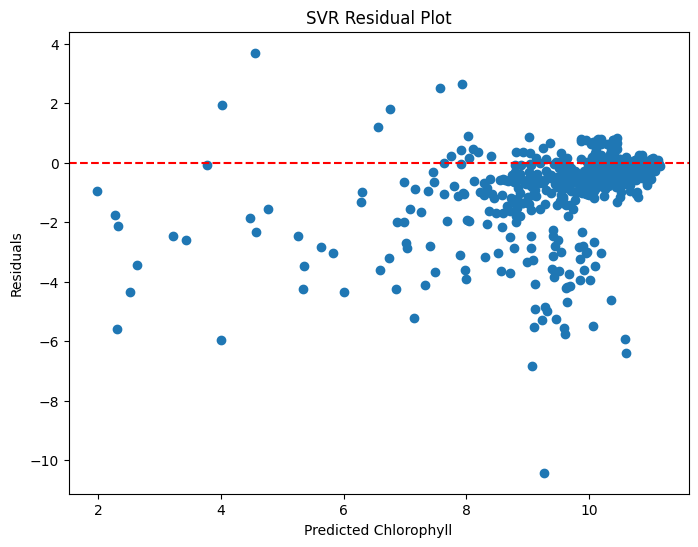

In [ ]:
#residual plot
residuals = y_test - pred_svr

plt.figure(figsize=(8,6))

plt.scatter(pred_svr, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Chlorophyll")
plt.ylabel("Residuals")

plt.title("SVR Residual Plot")

plt.show()

In [ ]:
#Taking the entire 2025 dataset and using it as input
prediction_2026 = df[df["Year"]==2025].copy()

In [ ]:
#Predict
X_2026 = prediction_2026[
    [
        "B3",
        "B4",
        "B5",
        "B8",
        "NDWI",
        "Month",
        "field_id",
        "Chlorophyll_a"
    ]
]

In [ ]:
#predict 2026
# Create X_2026 using the same feature columns as X_train
X_2026 = prediction_2026[X_train.columns]

# Scale using the same scaler fitted on the training data
X_2026_scaled = scaler.transform(X_2026)

# Predict 2026 chlorophyll
prediction_2026["Predicted_Chlorophyll_2026_SVR"] = best_svr.predict(X_2026_scaled)

prediction_2026.head()

,Year,Month,field_id,B3,B4,B5,B8,NDWI,Chlorophyll_a,Predicted_Chlorophyll_2026_SVR
3744,2025,1,0,0.090278,0.100278,0.111060,0.076112,0.109067,9.985310,10.226794
3745,2025,1,1,0.087753,0.092283,0.099603,0.052599,0.255062,10.447196,10.692023
3746,2025,1,2,0.087376,0.103112,0.123464,0.132039,-0.192650,8.559337,8.404482
3747,2025,1,3,0.129993,0.129922,0.162884,0.203147,-0.233950,7.202611,7.423231
3748,2025,1,4,0.167733,0.172509,0.196704,0.174084,-0.018210,9.277556,9.241150


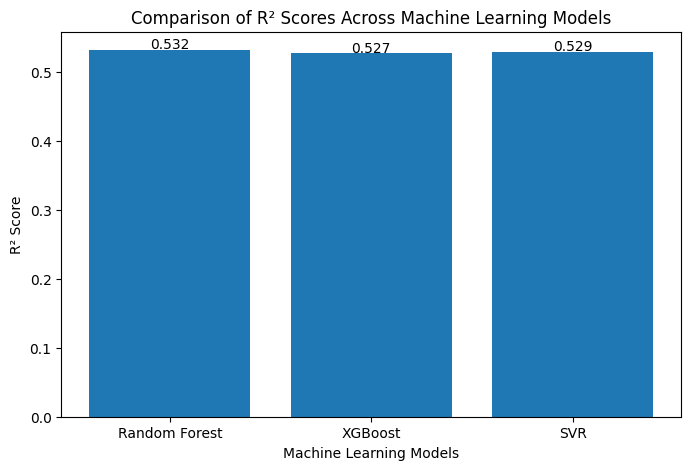

In [ ]:
#R^2 Comparison
import matplotlib.pyplot as plt

models = ["Random Forest", "XGBoost", "SVR"]
r2_scores = [0.5316, 0.5267, 0.5295]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title("Comparison of R² Scores Across Machine Learning Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("R² Score")

for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()

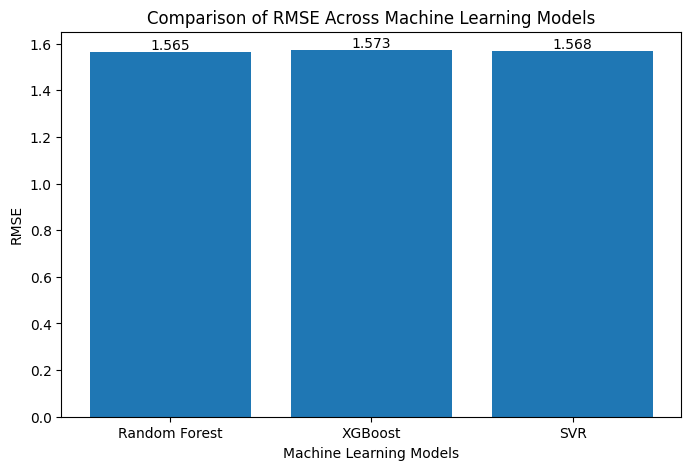

In [ ]:
#RMSE Comparison
models = ["Random Forest", "XGBoost", "SVR"]
rmse = [1.5648, 1.5730, 1.5684]

plt.figure(figsize=(8,5))

plt.bar(models, rmse)

plt.title("Comparison of RMSE Across Machine Learning Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("RMSE")

for i, v in enumerate(rmse):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

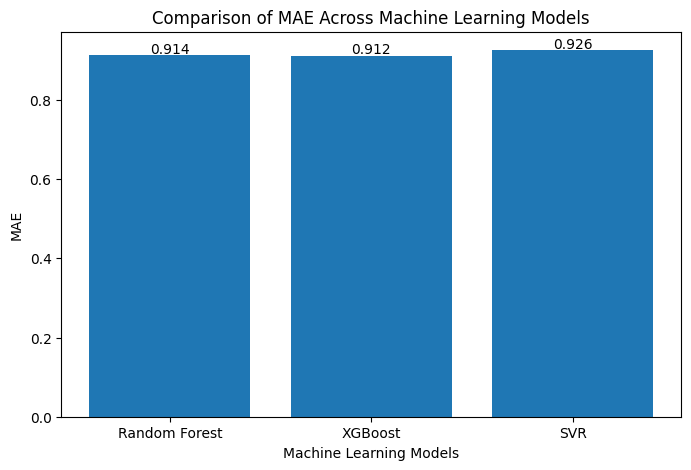

In [ ]:
#MAE Comparison
models = ["Random Forest", "XGBoost", "SVR"]
mae = [0.9138, 0.9123, 0.9262]

plt.figure(figsize=(8,5))

plt.bar(models, mae)

plt.title("Comparison of MAE Across Machine Learning Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("MAE")

for i, v in enumerate(mae):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()

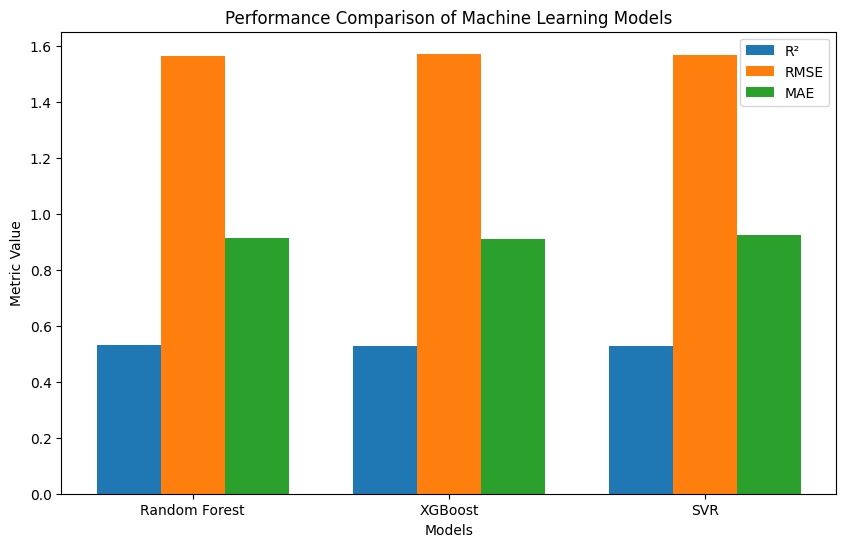

In [ ]:
#Combined comparison
import numpy as np
import matplotlib.pyplot as plt

models = ["Random Forest", "XGBoost", "SVR"]

r2 = [0.5316, 0.5267, 0.5295]
rmse = [1.5648, 1.5730, 1.5684]
mae = [0.9138, 0.9123, 0.9262]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, r2, width, label="R²")
plt.bar(x, rmse, width, label="RMSE")
plt.bar(x + width, mae, width, label="MAE")

plt.xticks(x, models)

plt.title("Performance Comparison of Machine Learning Models")

plt.xlabel("Models")

plt.ylabel("Metric Value")

plt.legend()

plt.show()